In [82]:
# ----------------------------------------------
# 1. IMPORTS
# ----------------------------------------------
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = (7,5)
plt.rcParams['font.size'] = 12


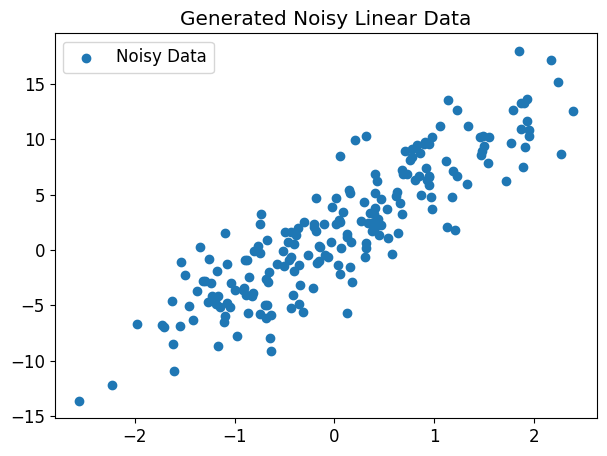

In [83]:
# ----------------------------------------------
# 2. GENERATE DATA (WITH NOISE)
# ----------------------------------------------

np.random.seed(0)

# Create 50 random x values
x = np.random.randn(200,1)

# True parameters (unknown to the model)
w_actual = 5
b_actual = 2

# Add noise to the data (Gaussian noise)
noise = np.random.randn(200,1) * 3   # adjust noise level if needed

# Generate y values from the true line + noise
y = w_actual * x + b_actual + noise

# Plot the noisy data
plt.scatter(x, y, label="Noisy Data")
plt.title("Generated Noisy Linear Data")
plt.legend()
plt.show()


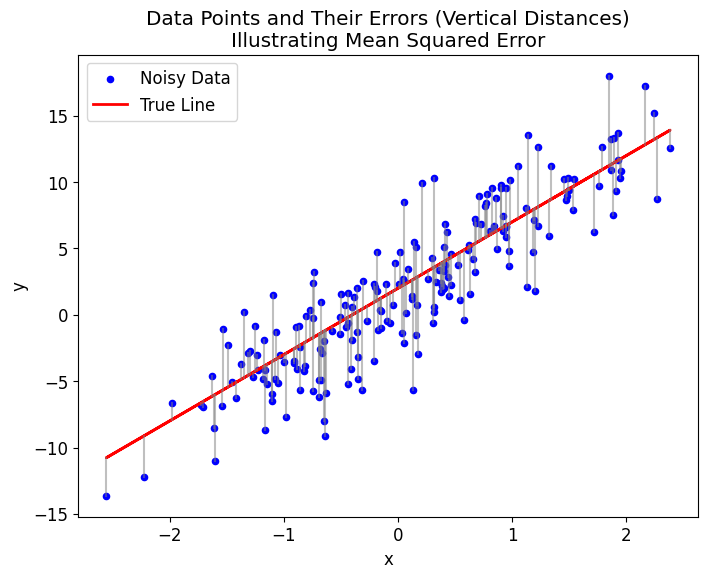

In [86]:
# ----------------------------------------------
# PLOT DATA + ERROR LINES
# ----------------------------------------------

# True line (without noise)
y_true = w_actual * x + b_actual

plt.figure(figsize=(8, 6))

# Plot noisy data
plt.scatter(x, y, label="Noisy Data", color="blue", s=20)

# Plot true line
plt.plot(x, y_true, color="red", label="True Line", linewidth=2)

# Draw vertical error lines for each point
for i in range(len(x)):
    plt.plot([x[i], x[i]], [y[i], y_true[i]], color="gray", alpha=0.5)

plt.title("Data Points and Their Errors (Vertical Distances)\nIllustrating Mean Squared Error")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [76]:
# ----------------------------------------------
# 3. GRADIENT DESCENT THEORY (SHORT EXPLANATION)
# ----------------------------------------------

# We want to learn:
#   y_hat = w*x + b
#
# Loss function: Mean Squared Error (MSE)
#   J = (1/(2m)) * Σ (y_hat - y)^2
#
# Gradients:
#   dJ/dw = (1/m) * Σ[ x_i * (w*x_i + b - y_i) ]
#   dJ/db = (1/m) * Σ[ (w*x_i + b - y_i) ]
#
# Update rules:
#   w := w - α * dJ/dw
#   b := b - α * dJ/db
#
# We'll implement these inside a function.


In [77]:
# ----------------------------------------------
# 4. GRADIENT DESCENT FUNCTION (LOOP VERSION)
# ----------------------------------------------

def descend(x, y, w, b, learning_rate):
    dJdw = 0.0
    dJdb = 0.0
    m = x.shape[0]  # number of samples
    
    # Compute gradients by looping over each data point
    for xi, yi in zip(x, y):
        y_hat = w * xi + b
        error = y_hat - yi
        
        dJdw += xi * error
        dJdb += error
    
    # Average gradients
    dJdw /= m
    dJdb /= m
    
    # Parameter updates
    w = w - learning_rate * dJdw
    b = b - learning_rate * dJdb

    return w, b


In [78]:
# ----------------------------------------------
# 5. TRAINING LOOP
# ----------------------------------------------

# Initial guesses (intentionally wrong)
w = 0.0
b = 0.0

learning_rate = 0.05
epochs = 300

# loss_history = []

# for epoch in range(epochs):
#     # Update w and b
#     w, b = descend(x, y, w, b, learning_rate)
    
#     # Predict using updated params
#     y_hat = w * x + b
    
#     # Compute MSE loss
#     loss = np.sum((y - y_hat)**2) / (2 * x.shape[0])
#     loss_history.append(loss)
    
#     # Print progress every 50 epochs
#     if epoch % 50 == 0:
#         print(f"Epoch {epoch} | Loss = {loss:.4f} | w = {w.item():.3f} | b = {b.item():.3f}")



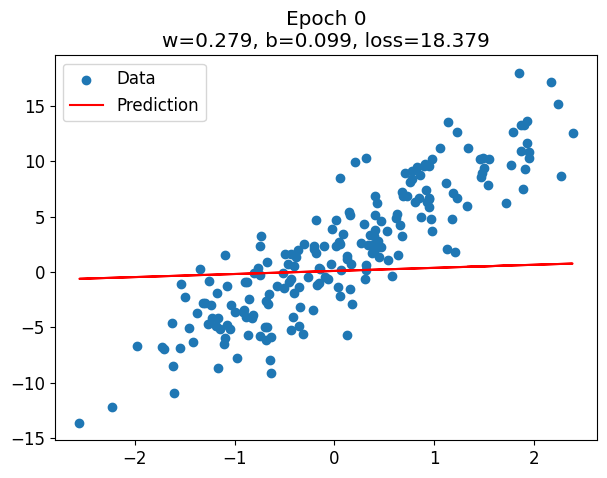

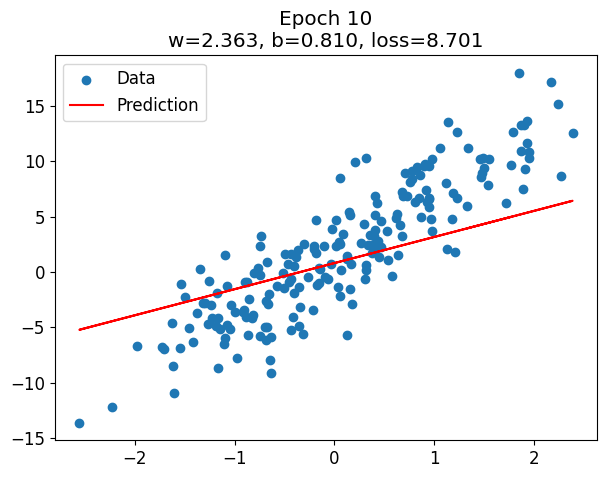

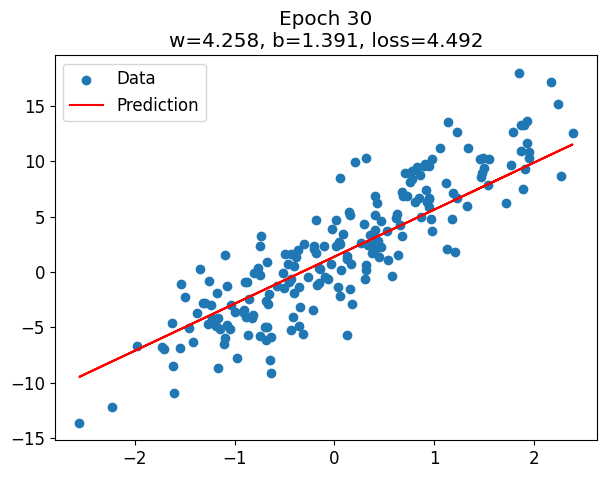

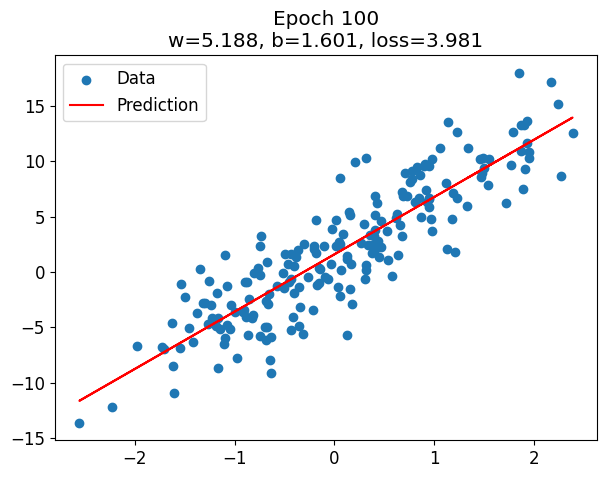

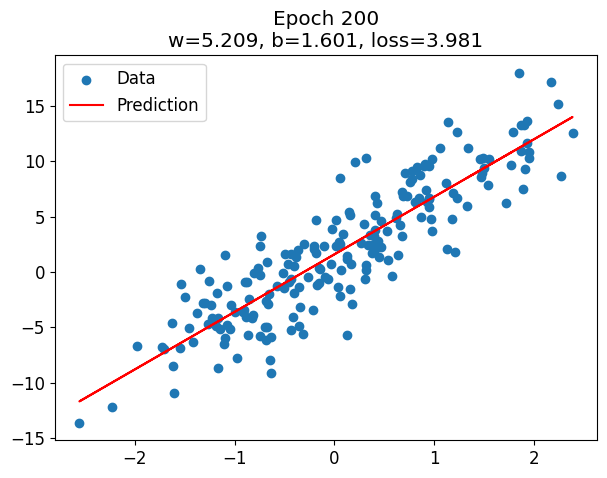

In [79]:
for epoch in range(epochs):
    w, b = descend(x, y, w, b, learning_rate)
    y_hat = w * x + b
    loss = np.sum((y - y_hat)**2) / (2 * x.shape[0])

    if epoch % 100 == 0 or epoch==10 or epoch==30:
        plt.figure()
        plt.scatter(x, y, label="Data")
        plt.plot(x, y_hat, color='red', label="Prediction")
        plt.title(f"Epoch {epoch}\nw={w.item():.3f}, b={b.item():.3f}, loss={loss:.3f}")
        plt.legend()
        plt.show()


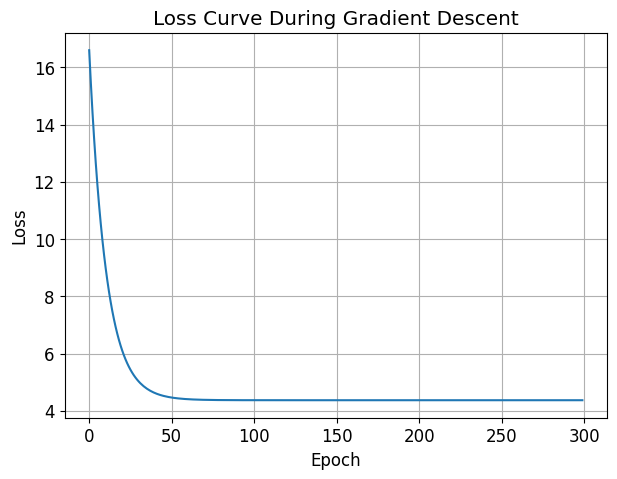

In [80]:
# ----------------------------------------------
# 6. PLOT LOSS CURVE
# ----------------------------------------------

plt.plot(loss_history)
plt.title("Loss Curve During Gradient Descent")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


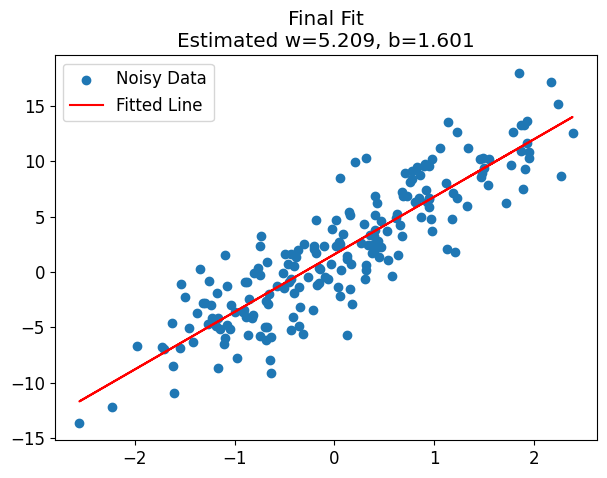

In [81]:
# ----------------------------------------------
# 7. PLOT FITTED LINE AGAINST NOISY DATA
# ----------------------------------------------

plt.scatter(x, y, label="Noisy Data")
plt.plot(x, y_hat, color='red', label="Fitted Line")
plt.title(f"Final Fit\nEstimated w={w.item():.3f}, b={b.item():.3f}")
plt.legend()
plt.show()
